In [36]:
!rm -rf lane_dataset/
!rm -rf sign_dataset/
!rm -f datasets.zip

In [37]:
!7z x datasets.zip


7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs Intel(R) Xeon(R) CPU @ 2.20GHz (406F0),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan         1 file, 193076 bytes (189 KiB)

Extracting archive: datasets.zip
--
Path = datasets.zip
Type = zip
Physical Size = 193076

  0%    Everything is Ok

Folders: 5
Files: 7
Size:       194741
Compressed: 193076


In [38]:
!pip install ultralytics -q

In [39]:
import os
from pathlib import Path
import json
import json
from pathlib import Path
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

In [40]:
import json, shutil, random
from pathlib import Path

# ==== CẤU HÌNH ====
SRC_DIR = Path("sign_dataset")          # thư mục gốc (images/, labels/*.json, classes.json)
DST_DIR = Path("sign_dataset_yolo")     # thư mục output chuẩn YOLO
VAL_RATIO = 0.2
SEED = 42

random.seed(SEED)

# Đọc classes.json -> danh sách tên lớp theo đúng thứ tự class_id
with open(SRC_DIR / "classes.json", "r", encoding="utf-8") as f:
    classes_data = json.load(f)
# classes_data có thể là dict {"0": "Biển báo cấm", ...} hoặc list -> chuẩn hóa về list theo id
if isinstance(classes_data, dict):
    class_names = [classes_data[str(i)] for i in range(len(classes_data))]
else:
    class_names = classes_data

# Tạo cấu trúc thư mục đích
for split in ["train", "val"]:
    (DST_DIR / "images" / split).mkdir(parents=True, exist_ok=True)
    (DST_DIR / "labels" / split).mkdir(parents=True, exist_ok=True)

label_files = sorted((SRC_DIR / "labels").glob("*.json"))
random.shuffle(label_files)
n_val = int(len(label_files) * VAL_RATIO)
val_set = set(label_files[:n_val])

converted, skipped = 0, 0
for jf in label_files:
    with open(jf, "r", encoding="utf-8") as f:
        data = json.load(f)

    img_name = data["image"]
    img_path = SRC_DIR / "images" / img_name
    if not img_path.exists():
        skipped += 1
        continue

    split = "val" if jf in val_set else "train"

    # Copy ảnh
    shutil.copy(img_path, DST_DIR / "images" / split / img_name)

    # Ghi label .txt cùng tên (đổi đuôi)
    txt_name = Path(img_name).stem + ".txt"
    lines = []
    for shape in data["shapes"]:
        cid = shape["class_id"]
        xc, yc, w, h = shape["bbox_yolo"]
        lines.append(f"{cid} {xc} {yc} {w} {h}")

    with open(DST_DIR / "labels" / split / txt_name, "w") as f:
        f.write("\n".join(lines))

    converted += 1

print(f"Đã convert {converted} ảnh, bỏ qua {skipped} ảnh thiếu file gốc.")

# Tạo data.yaml
yaml_content = f"""path: {DST_DIR.resolve()}
train: images/train
val: images/val

names:
""" + "\n".join([f"  {i}: {name}" for i, name in enumerate(class_names)])

with open(DST_DIR / "data.yaml", "w", encoding="utf-8") as f:
    f.write(yaml_content)

print("\n--- data.yaml ---")
print(yaml_content)

Đã convert 3 ảnh, bỏ qua 0 ảnh thiếu file gốc.

--- data.yaml ---
path: /content/sign_dataset_yolo
train: images/train
val: images/val

names:
  0: Biển báo cấm
  1: Biển đi thẳng
  2: Biển rẽ trái
  3: Biển rẽ phải
  4: Đèn xanh
  5: Đèn đỏ


Số lượng bbox theo class:
  0 (Biển báo cấm): 3
  1 (Biển đi thẳng): 1
  2 (Biển rẽ trái): 3
  4 (Đèn xanh): 2


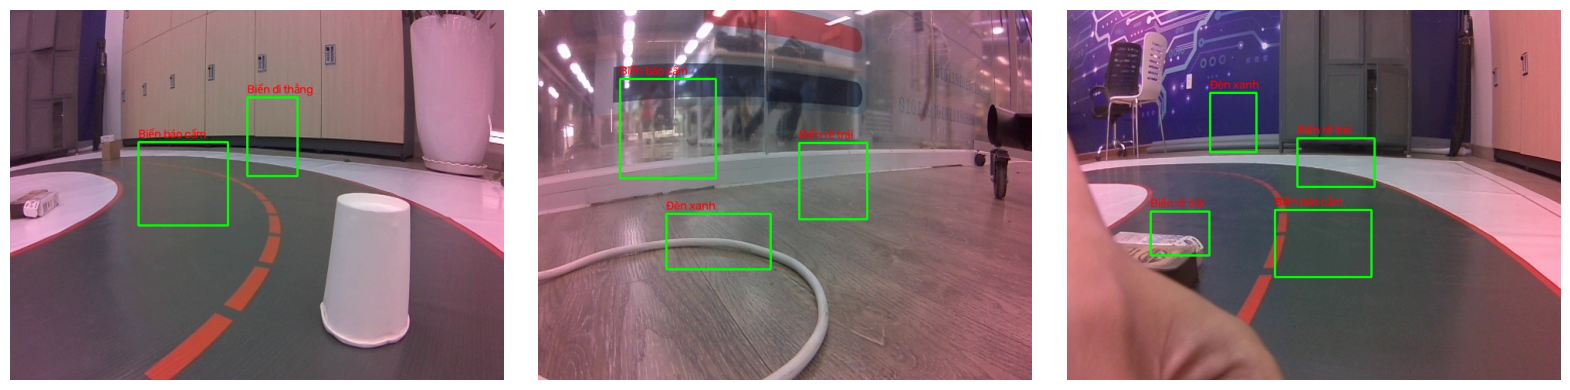

In [41]:
import cv2
import matplotlib.pyplot as plt
from collections import Counter

# Thống kê số lượng theo class
counter = Counter()
for txt_file in (DST_DIR / "labels").rglob("*.txt"):
    for line in txt_file.read_text().splitlines():
        if line.strip():
            cid = int(line.split()[0])
            counter[cid] += 1

print("Số lượng bbox theo class:")
for cid in sorted(counter):
    print(f"  {cid} ({class_names[cid]}): {counter[cid]}")

# Vẽ thử 4 ảnh train có bbox để kiểm tra label đúng vị trí
sample_imgs = list((DST_DIR / "images" / "train").glob("*.jpg"))[:4]
fig, axes = plt.subplots(1, len(sample_imgs), figsize=(16, 4))
for ax, img_path in zip(axes, sample_imgs):
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    label_path = DST_DIR / "labels" / "train" / (img_path.stem + ".txt")
    if label_path.exists():
        for line in label_path.read_text().splitlines():
            cid, xc, yc, bw, bh = map(float, line.split())
            x1 = int((xc - bw/2) * w); y1 = int((yc - bh/2) * h)
            x2 = int((xc + bw/2) * w); y2 = int((yc + bh/2) * h)
            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(img, class_names[int(cid)], (x1, max(y1-5,0)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)
    ax.imshow(img); ax.axis("off")
plt.tight_layout(); plt.show()

In [42]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")  # pretrained COCO weights, fine-tune tiếp

results = model.train(
    data=str(DST_DIR / "data.yaml"),
    epochs=100,
    imgsz=320,
    batch=16,
    patience=20,
    device=0,
    project="jetracer_sign",
    name="yolov8n_run1"
)

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.118 🚀 Python-3.12.13 torch-2.11.0+cpu 


ValueError: Invalid CUDA 'device=0' requested. Use 'device=cpu' or pass valid CUDA device(s) if available, i.e. 'device=0' or 'device=0,1,2,3' for Multi-GPU.

torch.cuda.is_available(): False
torch.cuda.device_count(): 0
os.environ['CUDA_VISIBLE_DEVICES']: None
See https://pytorch.org/get-started/locally/ for up-to-date torch install instructions if no CUDA devices are seen by torch.


In [15]:
data_dir = Path("sign_dataset")
list(data_dir.iterdir())

[PosixPath('sign_dataset/images'),
 PosixPath('sign_dataset/labels'),
 PosixPath('sign_dataset/classes.json')]

In [16]:
list(Path(data_dir / "images").iterdir())

[PosixPath('sign_dataset/images/img_1786604713916.jpg'),
 PosixPath('sign_dataset/images/img_1786604721780.jpg')]

In [19]:
list(Path(data_dir / "labels").iterdir())

[PosixPath('sign_dataset/labels/img_1786604713916.json'),
 PosixPath('sign_dataset/labels/img_1786604721780.json')]

In [24]:
with open(data_dir / "labels" / "img_1786604713916.json") as f:
    data = json.load(f)
data

{'image': 'img_1786604713916.jpg',
 'width': 640,
 'height': 480,
 'shapes': [{'class_id': 0,
   'label': 'Biển báo cấm',
   'bbox_pixel': {'x': 134, 'y': 184, 'w': 80, 'h': 103},
   'bbox_yolo': [0.271875, 0.490625, 0.125, 0.214583]},
  {'class_id': 0,
   'label': 'Biển báo cấm',
   'bbox_pixel': {'x': 275, 'y': 231, 'w': 55, 'h': 87},
   'bbox_yolo': [0.472656, 0.571875, 0.085938, 0.18125]},
  {'class_id': 2,
   'label': 'Biển rẽ trái',
   'bbox_pixel': {'x': 348, 'y': 146, 'w': 62, 'h': 82},
   'bbox_yolo': [0.592187, 0.389583, 0.096875, 0.170833]}]}

In [27]:
class SignDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = Path(data_dir)
        self.images_dir = self.data_dir / "images"
        self.labels_dir = self.data_dir / "labels"
        self.transform = transform

        # Lấy danh sách tất cả các file JSON nhãn
        self.label_files = sorted(list(self.labels_dir.glob("*.json")))

    def __len__(self):
        return len(self.label_files)

    def __getitem__(self, idx):
        # 1. Đọc file label JSON
        json_path = self.label_files[idx]
        with open(json_path, 'r', encoding='utf-8') as f:
            data = json.load(f)

        # 2. Đọc file ảnh tương ứng
        img_name = data['image']
        img_path = self.images_dir / img_name
        image = Image.open(img_path).convert("RGB")

        # 3. Trích xuất bounding boxes và class labels
        boxes = []
        labels = []

        for shape in data.get('shapes', []):
            labels.append(shape['class_id'])

            # Sử dụng bbox_yolo dạng [x_center, y_center, width, height] (đã chuẩn hóa 0-1)
            # Hoặc bbox_pixel dạng [x, y, w, h] tùy thuộc vào bài toán/mô hình của bạn
            boxes.append(shape['bbox_yolo'])

        # Chuyển đổi sang PyTorch Tensor
        boxes = torch.tensor(boxes, dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.int64)

        # 4. Áp dụng Augmentation/Transform nếu có
        if self.transform:
            image = self.transform(image)

        # Trả về dạng dictionary phù hợp cho bài toán Object Detection (như Faster R-CNN, YOLO, DETR,...)
        target = {
            'boxes': boxes,
            'labels': labels,
            'image_id': torch.tensor([idx])
        }

        return image, target


# Hàm collate_fn cần thiết vì số lượng bboxes trong mỗi ảnh khác nhau
def collate_fn(batch):
    return tuple(zip(*batch))

In [28]:
# Ví dụ về biến đổi ảnh (Transform)
transform = transforms.Compose([
    transforms.ToTensor(),
    # transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Khởi tạo Dataset
dataset = SignDataset(data_dir="sign_dataset", transform=transform)

# Khởi tạo DataLoader
dataloader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=collate_fn # Bắt buộc phải có collate_fn cho bài toán Object Detection
)

# Chạy thử vòng lặp kiểm tra
for images, targets in dataloader:
    print(f"Số lượng ảnh trong batch: {len(images)}")
    print(f"Kích thước ảnh đầu tiên: {images[0].shape}")
    print(f"Nhãn của ảnh đầu tiên: {targets[0]['labels']}")
    print(f"BBox của ảnh đầu tiên:\n{targets[0]['boxes']}")
    break

Số lượng ảnh trong batch: 2
Kích thước ảnh đầu tiên: torch.Size([3, 480, 640])
Nhãn của ảnh đầu tiên: tensor([0, 0, 2])
BBox của ảnh đầu tiên:
tensor([[0.2719, 0.4906, 0.1250, 0.2146],
        [0.4727, 0.5719, 0.0859, 0.1813],
        [0.5922, 0.3896, 0.0969, 0.1708]])


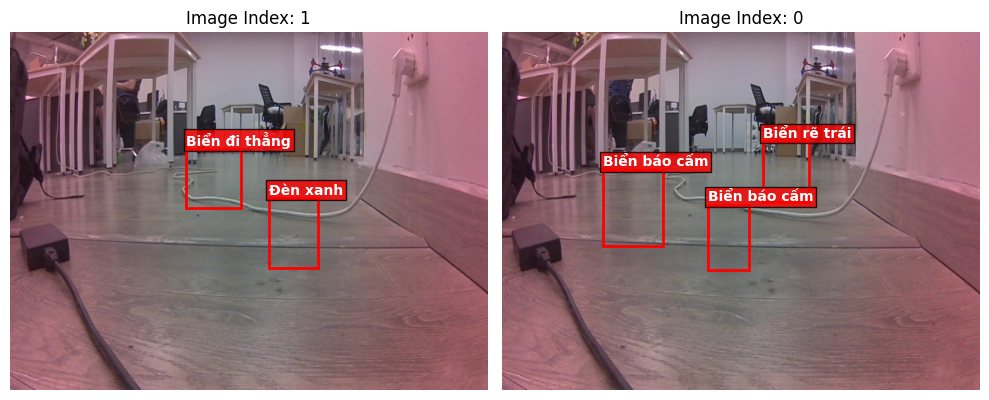

In [30]:
def load_class_names(json_path):
    with open(json_path, 'r', encoding='utf-8') as f:
        raw_classes = json.load(f)
    # Tự động ép kiểu key từ string sang integer để khớp với label_id của PyTorch
    return {int(k): v for k, v in raw_classes.items()}

# 2. Đọc file classes.json
classes_file = Path("sign_dataset/classes.json")
CLASS_NAMES = load_class_names(classes_file)

def visualize_batch(dataloader, class_names=CLASS_NAMES):
    # Lấy batch đầu tiên
    images, targets = next(iter(dataloader))

    batch_size = len(images)
    cols = min(4, batch_size)
    rows = (batch_size + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
    if batch_size == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for idx in range(batch_size):
        ax = axes[idx]

        # 1. Chuyển PyTorch Tensor ảnh về dạng NumPy để vẽ (C, H, W -> H, W, C)
        img = images[idx].permute(1, 2, 0).cpu().numpy()
        # Clip giá trị về khoảng [0, 1] phòng trường hợp ảnh chưa normalize chuẩn
        img = np.clip(img, 0, 1)

        height, width, _ = img.shape
        ax.imshow(img)

        boxes = targets[idx]['boxes']
        labels = targets[idx]['labels']

        # 2. Vẽ từng bounding box
        for box, label in zip(boxes, labels):
            box = box.numpy()
            label_id = label.item()
            label_name = class_names.get(label_id, f"Class {label_id}")

            # Giải mã bbox_yolo dạng [x_center, y_center, w, h] (đã chuẩn hóa 0-1) sang pixel
            x_center, y_center, w, h = box
            xmin = (x_center - w / 2) * width
            ymin = (y_center - h / 2) * height
            box_w = w * width
            box_h = h * height

            # Tạo hình chữ nhật cho BBox
            rect = patches.Rectangle(
                (xmin, ymin), box_w, box_h,
                linewidth=2, edgecolor='red', facecolor='none'
            )
            ax.add_patch(rect)

            # Vẽ nhãn chữ lên trên bbox
            ax.text(
                xmin, max(ymin - 5, 0), label_name,
                color='white', fontsize=10, weight='bold',
                bbox=dict(boxstyle='square,pad=0.2', facecolor='red', alpha=0.8)
            )

        ax.set_title(f"Image Index: {targets[idx]['image_id'].item()}")
        ax.axis('off')

    # Ẩn các ô thừa nếu batch_size không lấp đầy grid
    for idx in range(batch_size, len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()

# --- GỌI HÀM HIỂN THỊ ---
visualize_batch(dataloader)